# Estimation of stopping powers in liquid scintillator

In [1]:
pip install TDCRPy==2.20.10

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np

## Stopping power at a given energy

In [3]:
density = 0.96 # in g/cm3
energy = 200 # keV
result_alpha = td.TDCR_model_lib.stoppingpowerA(energy,rho=density)
result_electron = td.TDCR_model_lib.stoppingpower(energy*1e3,rho=density)
print(f"dE/dx = {result_alpha:.7g} keV/cm for alpha particles" )
print(f"dE/dx = {result_electron*1e3:.4g} keV/cm for electrons" )

dE/dx = 1913280 keV/cm for alpha particles
dE/dx = 2694 keV/cm for electrons


## Plot stopping power curves

### For alpha particles

The stopping power of alpha particles is obtained using tabulated values form the [ASTAR code](https://dx.doi.org/10.18434/T4NC7P). An extrapolated constant stopping power is taken below 1 keV.
     
        

Text(0, 0.5, 'd$E$/d$x$ /(MeV/cm)')

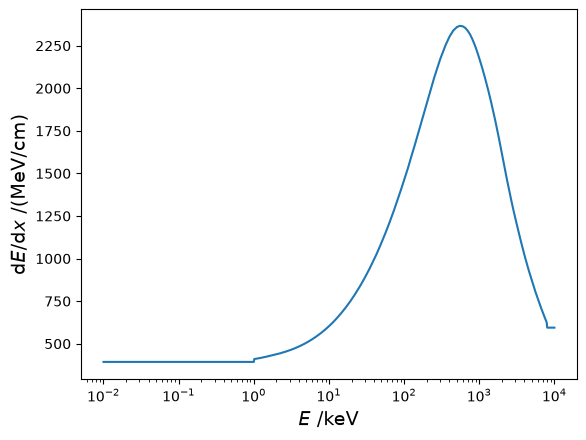

In [4]:
energy_vec = np.logspace(-2,4,1000) # in keV

w_a = []
for e in energy_vec:
        w_a.append(1e-3*td.TDCR_model_lib.stoppingpowerA(e,rho=density))

plt.figure("Stopping power - alpha particles")
plt.clf()
plt.plot(energy_vec,w_a)
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'd$E$/d$x$ /(MeV/cm)', fontsize=14)

### For electrons

The stopping power of electrons between 20 keV and 1000 keV is a mixture of a [radiative loss model](https://doi.org/10.1016/0020-708x(82)90244-7), and a [collision model](https://www.ijstr.org/final-print/jan2017/Calculations-Of-Stopping-Power-And-Range-Of-Electrons-Interaction-With-Different-Material-And-Human-Body-Parts.pdf). It is been validated agaisnt the [NIST model ESTAR](https://dx.doi.org/10.18434/T4NC7P) recommanded by the [ICRU Report 37](https://journals.sagepub.com/toc/cru/os-19/2).

Below 20 keV, the default model is from data calcaulted by [Tan and Xia](https://doi.org/10.1016/j.apradiso.2011.08.012). Other models are available:
* the [Joy and Luo](https://doi.org/10.1002/sca.4950110404) model below 20 keV,
* the [Marchal](https://doi.org/10.1080/09553007014550931) model below 400 eV,
* the [Ashley](https://iopscience.iop.org/article/10.1088/0953-8984/3/16/014/pdf) model below 100 eV,
* the [kossert and Grau Carles](https://doi.org/10.1016/j.apradiso.2009.11.048) model below 1 keV,
* the [Rao and Reddy](https://doi.org/10.1016/0020-708X(82)90244-7) model below 413 eV.

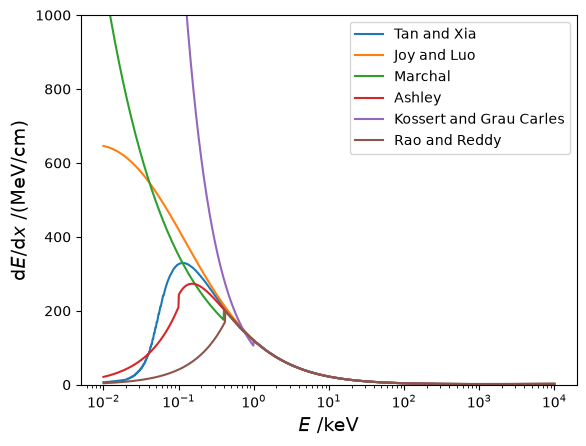

In [5]:
energy_vec = np.logspace(-2,4,1000) # in keV

w_e_tan, w_e_joy, w_e_marchal, w_e_ashley, w_e_kossert, w_e_rao = [], [], [], [], [], []
for e in energy_vec:
        w_a.append(td.TDCR_model_lib.stoppingpowerA(e,rho=density))
        w_e_tan.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density))
        w_e_joy.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="joy_luo"))
        w_e_marchal.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="marchal"))
        w_e_ashley.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="ashley"))
        w_e_kossert.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="kossert_graucarles"))
        w_e_rao.append(td.TDCR_model_lib.stoppingpower(e*1e3,rho=density,spmodel="rao_reddy"))

plt.figure("Stopping power - electrons")
plt.clf()
plt.plot(energy_vec,w_e_tan,label="Tan and Xia")
plt.plot(energy_vec,w_e_joy,label="Joy and Luo")
plt.plot(energy_vec,w_e_marchal,label="Marchal")
plt.plot(energy_vec,w_e_ashley,label="Ashley")
plt.plot(energy_vec,w_e_kossert,label="Kossert and Grau Carles")
plt.plot(energy_vec,w_e_rao,label="Rao and Reddy")
plt.xscale('log')
plt.ylim([0, 1000])
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'd$E$/d$x$ /(MeV/cm)', fontsize=14)
plt.legend()